In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [59]:
df = pd.read_csv('../dataset/UniversalBank.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [60]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [61]:
loc_df = df.drop(["ID", "ZIP Code"], axis=1)
loc_df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [62]:
# Find the abnormal values
loc_experience_df = df[df["Experience"] < 0]
loc_experience_df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


### Plotting the correlations between features

<Axes: title={'center': 'Heatmap showing the Correlations between all features'}>

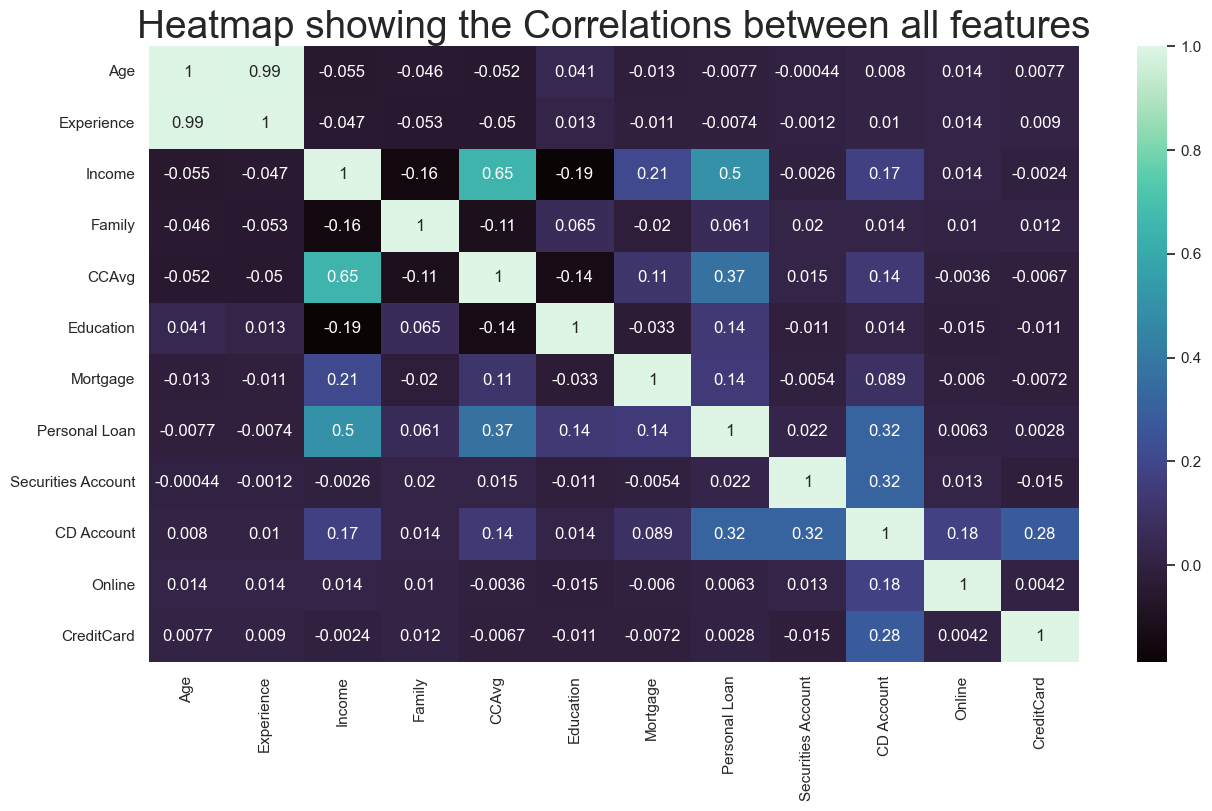

In [63]:
plt.figure(figsize=(15,8))
plt.title("Heatmap showing the Correlations between all features", fontsize = 28)
sns.heatmap(loc_df.corr(), annot=True, cmap='mako')

In [64]:
# Because the data in Experience have negaitve value (invalid).
# Base on Correlation between [Age] and [Experience] = 0.99
# Therefore, remove Experience
loc_df = loc_df.drop(["Experience"], axis=1)
loc_df

,Age,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,29,40,1,1.9,3,0,0,0,0,1,0
4996,30,15,4,0.4,1,85,0,0,0,1,0
4997,63,24,2,0.3,3,0,0,0,0,0,0
4998,65,49,3,0.5,2,0,0,0,0,1,0


### Descriptive Statistics

In [65]:
stats_cols = ['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage']

stats = loc_df[stats_cols].describe()
print(stats)

               Age       Income       Family        CCAvg    Education  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     45.338400    73.774200     2.396400     1.937938     1.881000   
std      11.463166    46.033729     1.147663     1.747659     0.839869   
min      23.000000     8.000000     1.000000     0.000000     1.000000   
25%      35.000000    39.000000     1.000000     0.700000     1.000000   
50%      45.000000    64.000000     2.000000     1.500000     2.000000   
75%      55.000000    98.000000     3.000000     2.500000     3.000000   
max      67.000000   224.000000     4.000000    10.000000     3.000000   

          Mortgage  
count  5000.000000  
mean     56.498800  
std     101.713802  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%     101.000000  
max     635.000000  


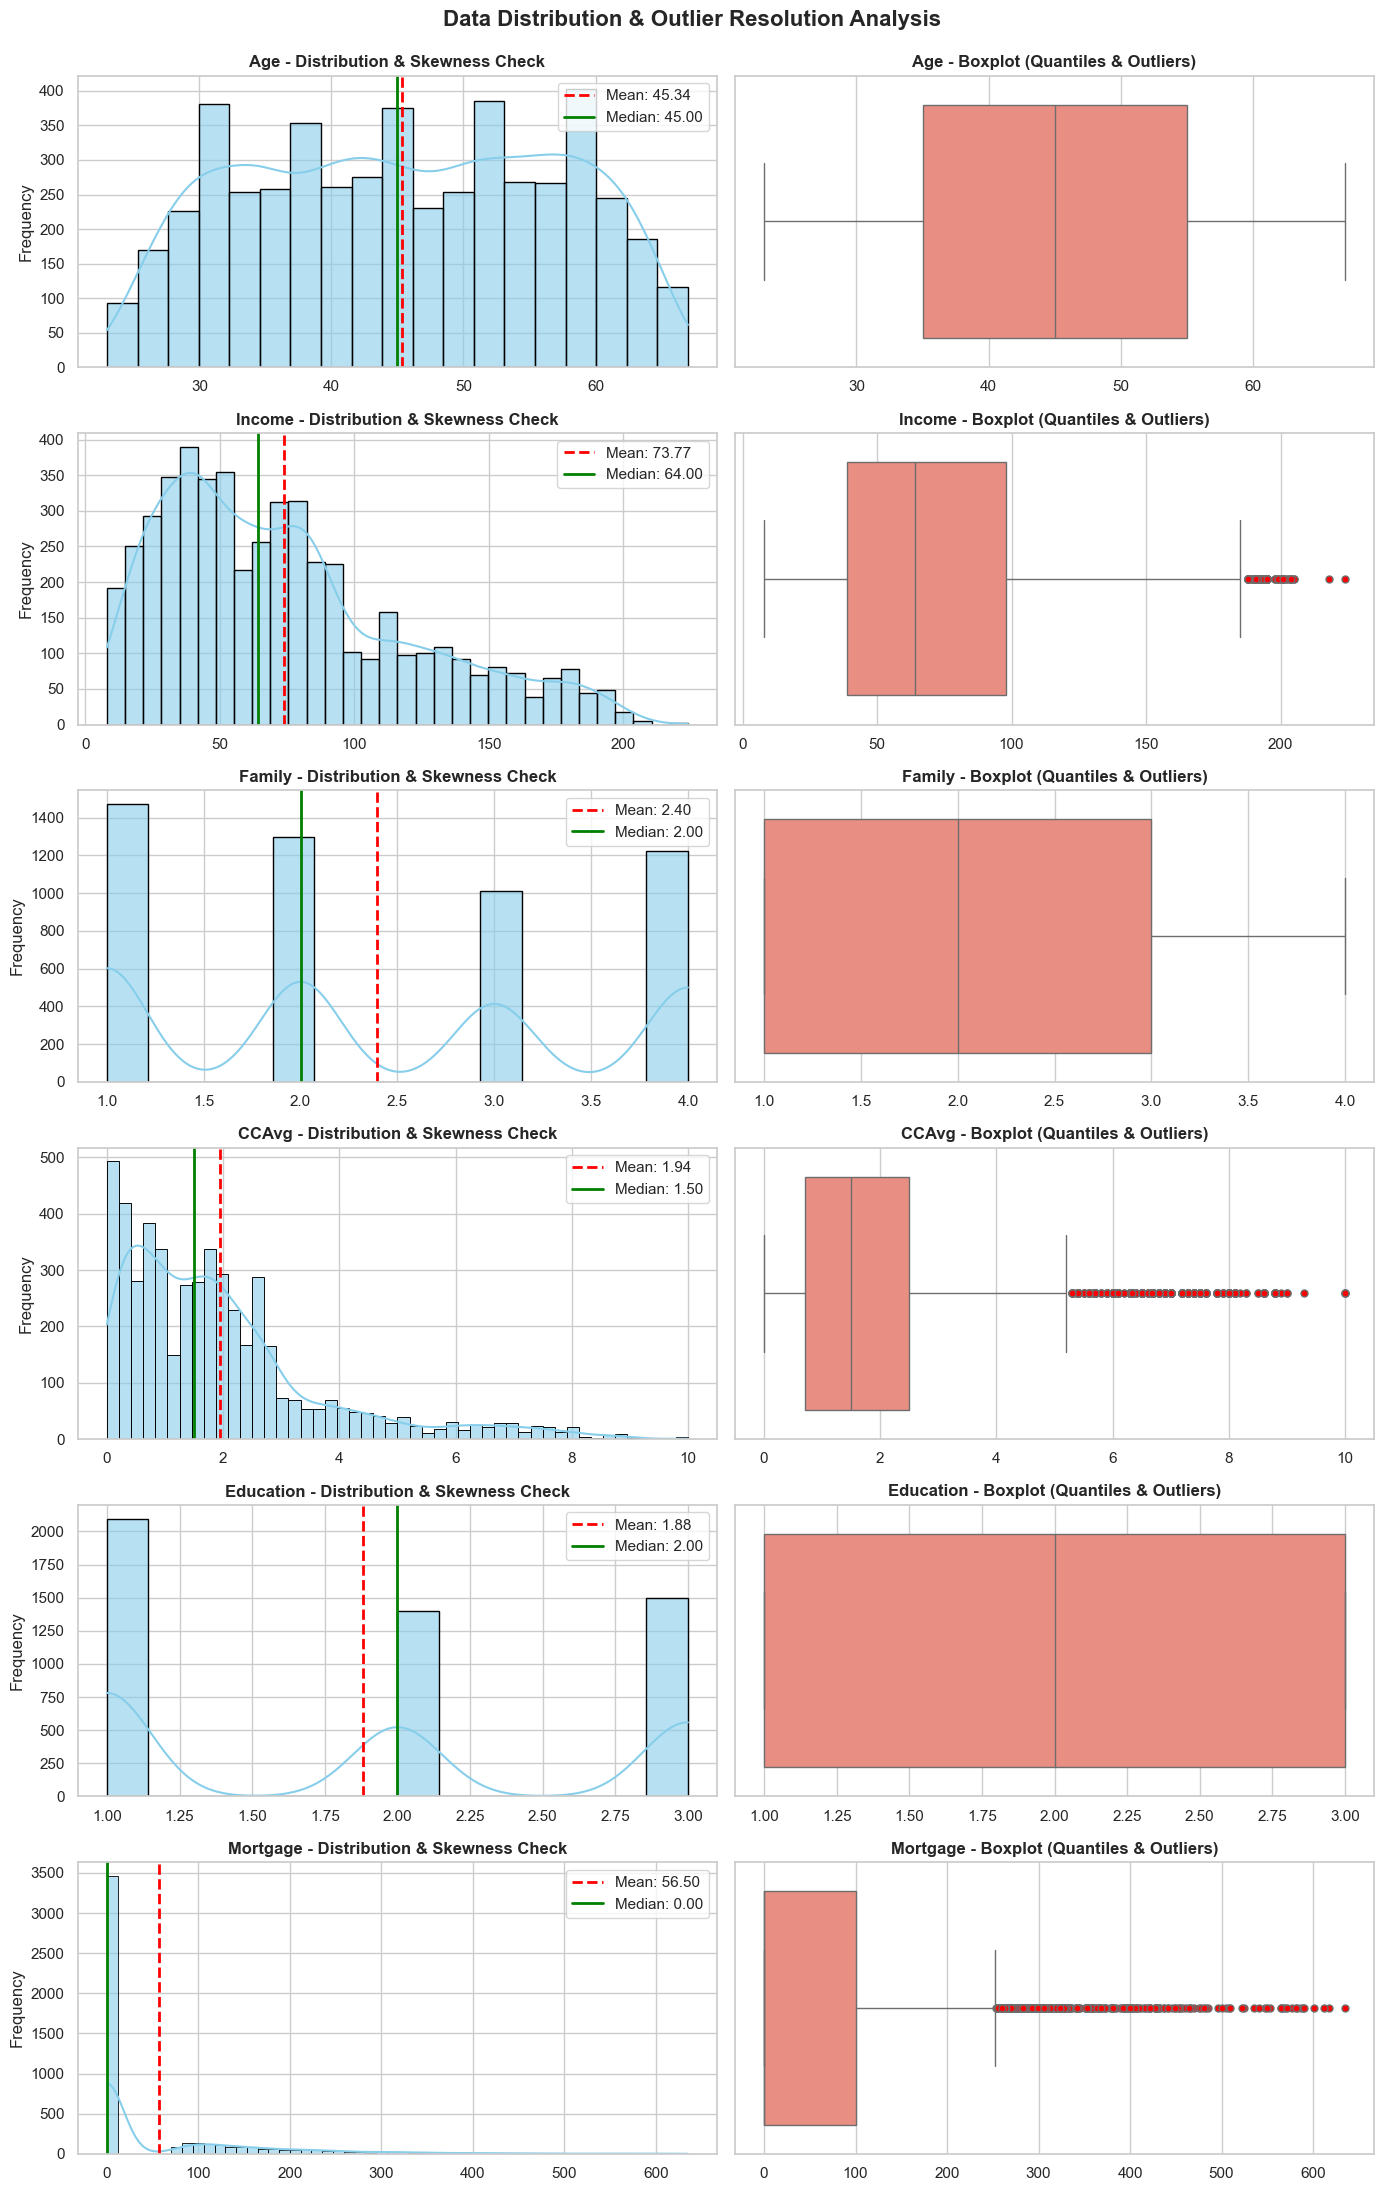

In [66]:
#Set overall plot styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(14,22))
fig.suptitle('Data Distribution & Outlier Resolution Analysis', fontsize=16, fontweight='bold', y=0.995)

for i, col in enumerate(stats_cols):
    mean_val = loc_df[col].mean()
    median_val = loc_df[col].median()
    
    # 1. Left Subplot: Histogram + Kernel Density Estimate (KDE)
    sns.histplot(loc_df[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black', alpha=0.6)
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i, 0].set_title(f'{col} - Distribution & Skewness Check', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend(loc='upper right')
    
    # 2. Right Subplot: Boxplot for IQR & Outlier Visual Inspection
    sns.boxplot(x=loc_df[col], ax=axes[i, 1], color='salmon', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5})
    axes[i, 1].set_title(f'{col} - Boxplot (Quantiles & Outliers)', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

### Check the Correlate between Family and CreditCard

In [80]:
# P-value
p_value = 7.815

# Applying Chi-Squared for the evaluation of Family
obs_family = pd.crosstab(loc_df['Family'], loc_df['CreditCard']).values
r_obs = obs_family.sum(axis=0, keepdims=True)
c_obs = obs_family.sum(axis=1, keepdims=True)

# Determine the Degree of Freedom
degree_of_free = (obs_family.shape[0] - 1) * (obs_family.shape[1] - 1)

# Calculate the expected of frequency
q = (c_obs @ r_obs) / loc_df.shape[0]

# Perform the Chi-Square Test
chi_square = np.sum((obs_family - q) ** 2 / q)

if (chi_square <= p_value):
    print(f"Chi-Square: {chi_square}")
    print("Because the p-value is more than a certant significance level, means that category levels highly correlate with each other.")
else:
    print("Because the p-value is less than a certant siginificance level, so reject null hypithesis")


Chi-Square: 3.8389356603949794
Because the p-value is more than a certant significance level, means that category levels highly correlate with each other.


### Check the Correlate between Education and CreditCard

In [79]:
# P-value
p_value = 7.815

# Applying Chi-Squared for the evaluation of Family
obs_education = pd.crosstab(loc_df['Education'], loc_df['CreditCard']).values
r_obs = obs_education.sum(axis=0, keepdims=True)
c_obs = obs_education.sum(axis=1, keepdims=True)


# Determine the Degree of Freedom
degree_of_free = (obs_education.shape[0] - 1) * (obs_education.shape[1] - 1)

# Calculate the expected of frequency
q = (c_obs @ r_obs) / loc_df.shape[0]

# Perform the Chi-Square Test
chi_square = np.sum((obs_education - q) ** 2 / q)

if (chi_square <= p_value):
    print(f"Chi-Square: {chi_square}")
    print("Because the p-value is more than a certant significance level, means that category levels highly correlate with each other.")
else:
    print("Because the p-value is less than a certant siginificance level, so reject null hypithesis")


Chi-Square: 1.2410828349087826
Because the p-value is more than a certant significance level, means that category levels highly correlate with each other.


In [ ]:
obs = pd.crosstab(loc_df['Education'], loc_df['CreditCard']).values
obs_row = obs.sum(axis=1, keepdims=True)
obs_col = obs.sum(axis=0, keepdims=True)
exp = obs_row @ obs_col / obs.sum()
chi2_stat = np.sum((obs - exp) ** 2 / exp)

df_chi2 = (obs.shape[0] - 1) * (obs.shape[1] - 1)

print(f"[Manual Chi-Square] Stat: {chi2_stat:.4f} | Degrees of Freedom: {df_chi2}")

[[1463  633]
 [1003  400]
 [1064  437]]
[[2096]
 [1403]
 [1501]]
[[3530 1470]]
[Manual Chi-Square] Stat: 1.2411 | Degrees of Freedom: 2


In [ ]:
zero_class = loc_df[loc_df["CreditCard"] == 1]
zero_class

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4,35,8,45,4,1.0,2,0,0,0,0,0,1
7,50,24,22,1,0.3,3,0,0,0,0,0,1
15,60,30,22,1,1.5,3,0,0,0,0,1,1
19,55,28,21,1,0.5,2,0,0,1,0,0,1
24,36,11,152,2,3.9,1,159,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,4,2.3,3,0,0,0,0,0,1
4988,34,8,85,1,2.5,1,136,0,0,0,0,1
4990,55,25,58,4,2.0,3,219,0,0,0,0,1
4991,51,25,92,1,1.9,2,100,0,0,0,0,1


In [ ]:
one_class = loc_df[loc_df["CreditCard"] == 0]
one_class

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
5,37,13,29,4,0.4,2,155,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4994,64,40,75,3,2.0,3,0,0,0,0,1,0
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0


### Scatter Plot

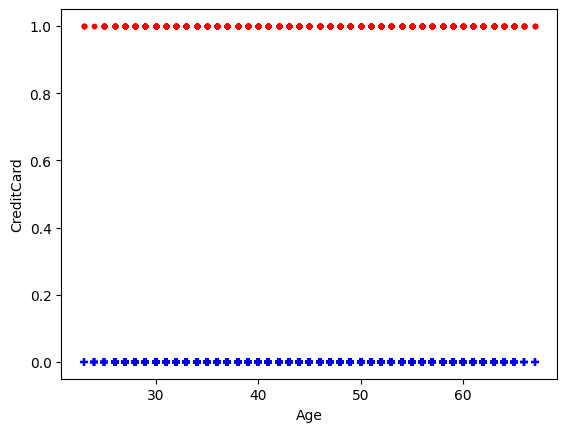

In [38]:
plt.xlabel("Age")
plt.ylabel("CreditCard")
plt.scatter(one_class["Age"], one_class["CreditCard"], color="blue", marker="+")
plt.scatter(zero_class["Age"], zero_class["CreditCard"], color="red", marker=".")

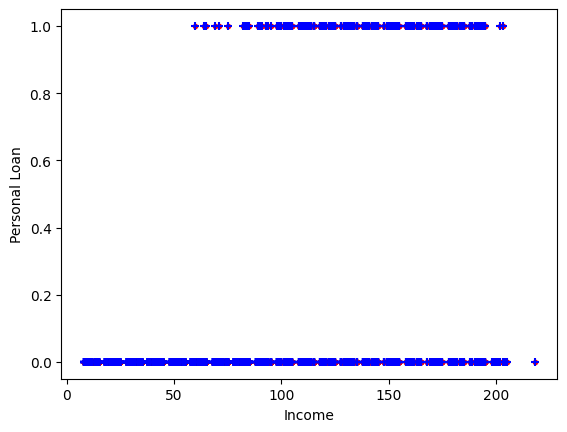

In [23]:
plt.xlabel("Income")
plt.ylabel("Personal Loan")
plt.scatter(one_class["Income"], one_class["Personal Loan"], color="red", marker=".")
plt.scatter(one_class["Income"], one_class["Personal Loan"], color="blue", marker="+")

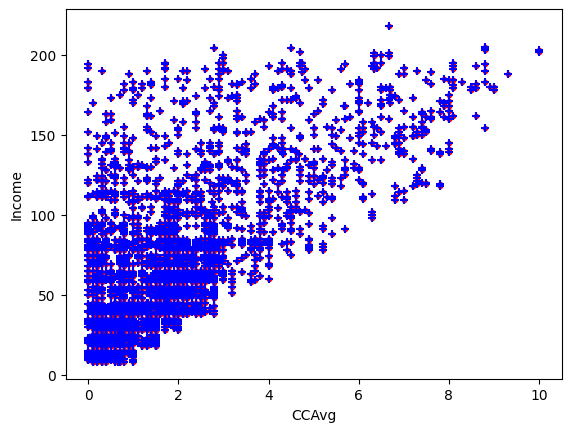

In [26]:
plt.xlabel("CCAvg")
plt.ylabel("Income")
plt.scatter(one_class["CCAvg"], one_class["Income"], color="red", marker=".")
plt.scatter(one_class["CCAvg"], one_class["Income"], color="blue", marker="+")

### Scaling Data

In [29]:
def standard_scaler(X):

    mean = np.sum(X, axis=0) / X.shape[0]

    variance = np.sum((X - mean) ** 2, axis=0) / X.shape[0]
    std = np.sqrt(variance)

    std_scaler = (X - mean) / std

    return std_scaler

In [ ]:
scaled_df = standard_scaler(loc_df.drop("CreditCard", axis=1))
scaled_df

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online
0,-1.774417,-1.666078,-0.538229,1.397414,-0.193385,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
1,-0.029524,-0.096330,-0.864109,0.525991,-0.250611,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
2,-0.552992,-0.445163,-1.363793,-1.216855,-0.536736,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
3,-0.901970,-0.968413,0.569765,-1.216855,0.436091,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
4,-0.901970,-1.055621,-0.625130,1.397414,-0.536736,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.425438,-1.491662,-0.733757,-1.216855,-0.021710,1.332484,-0.555524,-0.325875,-0.341423,-0.25354,0.821951
4996,-1.338194,-1.404454,-1.276892,1.397414,-0.880087,-1.049078,0.280238,-0.325875,-0.341423,-0.25354,0.821951
4997,1.540880,1.647835,-1.081363,-0.345432,-0.937312,1.332484,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
4998,1.715370,1.735043,-0.538229,0.525991,-0.822862,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,0.821951


In [ ]:
y = loc_df["CreditCard"]
y

0       0
1       0
2       0
3       0
4       1
       ..
4995    0
4996    0
4997    0
4998    0
4999    1
Name: CreditCard, Length: 5000, dtype: int64

### Implementation of SVM